In [ ]:
!pip install ucimlrepo wfdb openpyxl pillow nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.7 MB/s eta 0:00:00


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

import wfdb

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

Tabular Data


In [ ]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)


X = heart_disease.data.features

y = heart_disease.data.targets

print("Dataset loaded successfully!")
print(X.head())

Dataset loaded successfully!
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 feature records:")
display(X.head())

print("\nFirst 5 target records:")
display(y.head())

Features shape: (303, 13)
Target shape: (303, 1)

First 5 feature records:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



First 5 target records:


,num
0,0
1,2
2,1
3,0
4,0


In [ ]:
print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.columns[0])

Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target column:
num


In [ ]:
df = pd.concat([X, y], axis=1)

print("Complete dataset shape:", df.shape)

display(df.head())

Complete dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [ ]:
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


In [ ]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 age
[63 67 37 41 56 62 57 53 44 52 48 54 49 64 58 60 50 66 43 40 69 59 42 55
 61 65 71 51 46 45 39 68 47 34 35 29 70 77 38 74 76]

 sex
[1 0]

 cp
[1 4 3 2]

 trestbps
[145 160 120 130 140 172 150 110 132 117 135 112 105 124 125 142 128 170
 155 104 180 138 108 134 122 115 118 100 200  94 165 102 152 101 126 174
 148 178 158 192 129 144 123 136 146 106 156 154 114 164]

 chol
[233 286 229 250 204 236 268 354 254 203 192 294 256 263 199 168 239 275
 266 211 283 284 224 206 219 340 226 247 167 230 335 234 177 276 353 243
 225 302 212 330 175 417 197 198 290 253 172 273 213 305 216 304 188 282
 185 232 326 231 269 267 248 360 258 308 245 270 208 264 321 274 325 235
 257 164 141 252 255 201 222 260 182 303 265 309 307 249 186 341 183 407
 217 288 220 209 227 261 174 281 221 205 240 289 318 298 564 246 322 299
 300 293 277 214 207 223 160 394 184 315 409 244 195 196 126 313 259 200
 262 215 228 193 271 210 327 149 295 306 178 237 218 242 319 166 180 311
 278 342 169 187 157 176 241 131]



In [ ]:
print("Original target values:")
print(df["num"].value_counts().sort_index())

Original target values:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [ ]:
df["num"] = (df["num"] > 0).astype(int)

In [ ]:
print("Binary target:")
print(df["num"].value_counts())

Binary target:
num
0    164
1    139
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [ ]:
for column in df.columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

In [ ]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [ ]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

display(df.head())

Shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


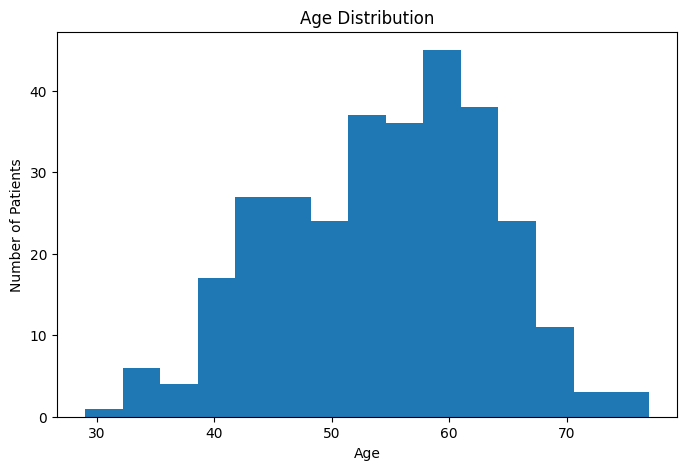

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")

plt.show()

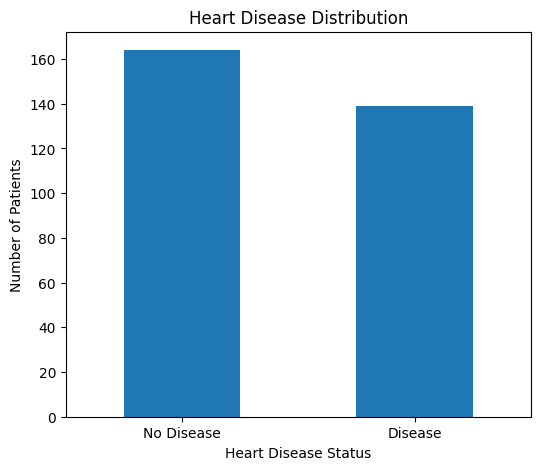

In [ ]:
plt.figure(figsize=(6, 5))

df["num"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"],
    rotation=0
)

plt.show()

/tmp/ipykernel_3565/866623636.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


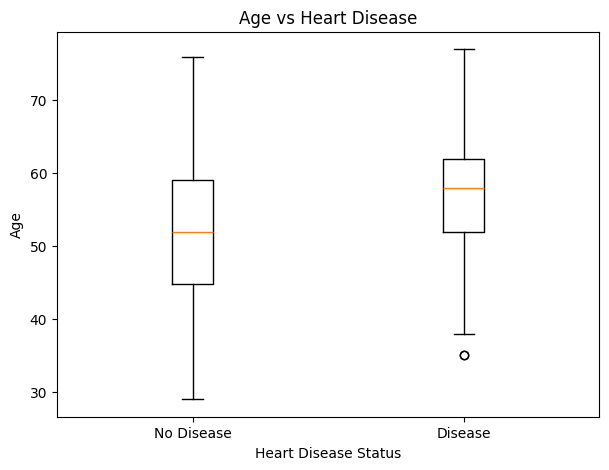

In [ ]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df[df["num"] == 0]["age"],
        df[df["num"] == 1]["age"]
    ],
    labels=["No Disease", "Disease"]
)

plt.xlabel("Heart Disease Status")
plt.ylabel("Age")
plt.title("Age vs Heart Disease")

plt.show()

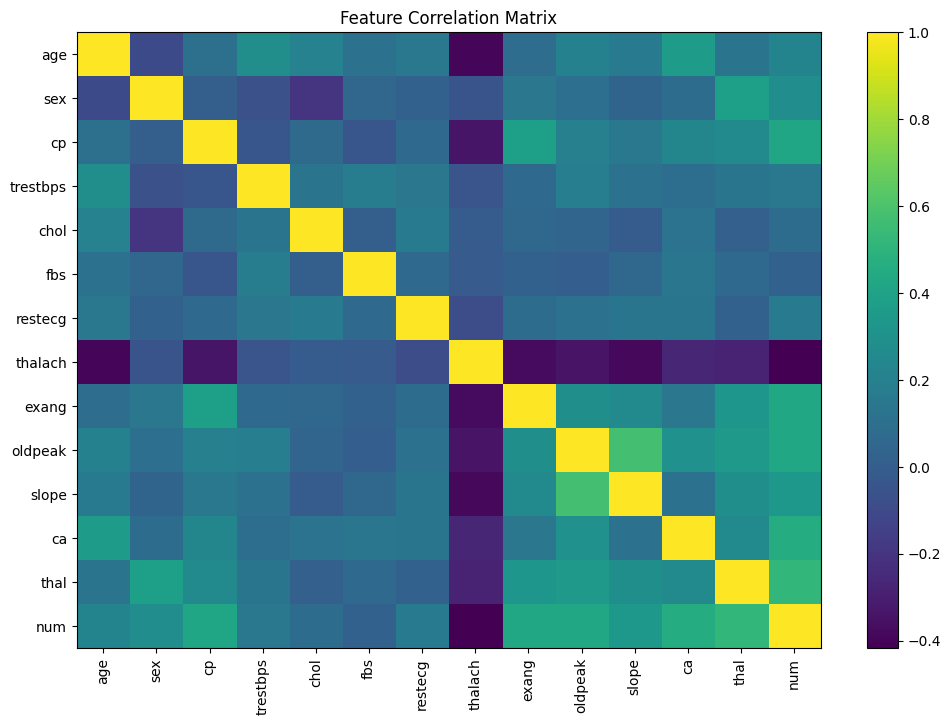

In [ ]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
X = df.drop("num", axis=1)
y = df["num"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


In [ ]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.8852459016393442
Accuracy percentage: 88.52 %


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [ ]:
auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC:", auc)

ROC-AUC: 0.9664502164502166


[[28  5]
 [ 2 26]]


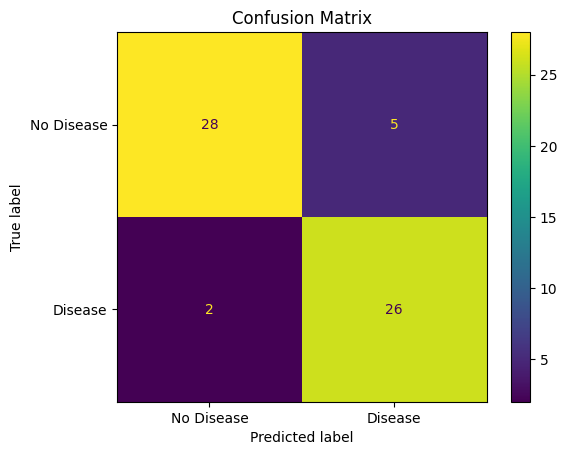

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [ ]:
df.to_csv(
    "cleaned_heart_disease.csv",
    index=False
)

print("Cleaned dataset saved.")
print(os.path.exists("cleaned_heart_disease.csv"))

Cleaned dataset saved.
True


In [ ]:
df.to_csv("heart_data.csv", index=False)

In [ ]:
csv_data = pd.read_csv("heart_data.csv")

display(csv_data.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df.to_excel("heart_data.xlsx", index=False)

In [ ]:
excel_data = pd.read_excel("heart_data.xlsx")

display(excel_data.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [ ]:
df.to_json(
    "heart_data.json",
    orient="records",
    indent=4
)
json_data = pd.read_json("heart_data.json")

display(json_data.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [ ]:
def detect_file_type(filename):

    extension = os.path.splitext(filename)[1].lower()

    if extension == ".csv":
        return "CSV / Tabular"

    elif extension in [".xls", ".xlsx"]:
        return "Excel / Tabular"

    elif extension == ".json":
        return "JSON / Structured"

    elif extension in [".txt"]:
        return "Plain Text"

    elif extension in [".pdf"]:
        return "PDF / Text"

    elif extension in [".png", ".jpg", ".jpeg", ".tiff"]:
        return "Image"

    elif extension in [".dat", ".hea", ".atr"]:
        return "WFDB Signal"

    elif extension in [".dcm"]:
        return "DICOM Medical Image"

    elif extension in [".nii", ".nii.gz"]:
        return "NIfTI Medical Image"

    else:
        return "Unknown"

In [ ]:
test_files = [
    "heart.csv",
    "heart.xlsx",
    "heart.json",
    "clinical_note.txt",
    "medical_image.png",
    "100.dat",
    "100.hea",
    "100.atr",
    "scan.dcm",
    "brain.nii"
]

for file in test_files:
    print(file, "→", detect_file_type(file))

heart.csv → CSV / Tabular
heart.xlsx → Excel / Tabular
heart.json → JSON / Structured
clinical_note.txt → Plain Text
medical_image.png → Image
100.dat → WFDB Signal
100.hea → WFDB Signal
100.atr → WFDB Signal
scan.dcm → DICOM Medical Image
brain.nii → NIfTI Medical Image


In [ ]:
def inspect_tabular(data):

    print("========== TABULAR DATA ==========")
    print("Shape:", data.shape)

    print("\nColumns:")
    print(data.columns.tolist())

    print("\nData Types:")
    print(data.dtypes)

    print("\nMissing Values:")
    print(data.isnull().sum())

    print("\nFirst 5 Rows:")
    display(data.head())

In [ ]:
inspect_tabular(df)

========== TABULAR DATA ==========
Shape: (303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Textual Data


In [ ]:
clinical_note = """
Patient reports chest pain during physical activity.
The patient experiences shortness of breath and occasional dizziness.
Resting blood pressure is elevated.
The patient has a history of high cholesterol.
"""

In [ ]:
with open("clinical_note.txt", "w") as file:
    file.write(clinical_note)

print("Clinical note saved.")

Clinical note saved.


In [ ]:
with open("clinical_note.txt", "r") as file:
    text = file.read()

print(text)


Patient reports chest pain during physical activity.
The patient experiences shortness of breath and occasional dizziness.
Resting blood pressure is elevated.
The patient has a history of high cholesterol.



In [ ]:
print("Number of characters:", len(text))
print("Number of words:", len(text.split()))

Number of characters: 207
Number of words: 29


In [ ]:
import re

clean_text = text.lower()

clean_text = re.sub(
    r"[^a-zA-Z\s]",
    "",
    clean_text
)

print(clean_text)


patient reports chest pain during physical activity
the patient experiences shortness of breath and occasional dizziness
resting blood pressure is elevated
the patient has a history of high cholesterol



In [ ]:
tokens = clean_text.split()

print(tokens)

['patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'the', 'patient', 'experiences', 'shortness', 'of', 'breath', 'and', 'occasional', 'dizziness', 'resting', 'blood', 'pressure', 'is', 'elevated', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'cholesterol']


In [ ]:
word_counts = Counter(tokens)

print(word_counts)

Counter({'patient': 3, 'the': 2, 'of': 2, 'reports': 1, 'chest': 1, 'pain': 1, 'during': 1, 'physical': 1, 'activity': 1, 'experiences': 1, 'shortness': 1, 'breath': 1, 'and': 1, 'occasional': 1, 'dizziness': 1, 'resting': 1, 'blood': 1, 'pressure': 1, 'is': 1, 'elevated': 1, 'has': 1, 'a': 1, 'history': 1, 'high': 1, 'cholesterol': 1})


In [ ]:
print(
    word_counts.most_common(10)
)

[('patient', 3), ('the', 2), ('of', 2), ('reports', 1), ('chest', 1), ('pain', 1), ('during', 1), ('physical', 1), ('activity', 1), ('experiences', 1)]


In [ ]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

filtered_tokens = [
    word
    for word in tokens
    if word not in stop_words
]

print(filtered_tokens)

['patient', 'reports', 'chest', 'pain', 'physical', 'activity', 'patient', 'experiences', 'shortness', 'breath', 'occasional', 'dizziness', 'resting', 'blood', 'pressure', 'elevated', 'patient', 'history', 'high', 'cholesterol']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
filtered_counts = Counter(filtered_tokens)

print(filtered_counts.most_common(10))

[('patient', 3), ('reports', 1), ('chest', 1), ('pain', 1), ('physical', 1), ('activity', 1), ('experiences', 1), ('shortness', 1), ('breath', 1), ('occasional', 1)]


In [ ]:
def inspect_text(text):

    words = text.split()

    print("========== TEXT DATA ==========")
    print("Characters:", len(text))
    print("Words:", len(words))
    print("Unique words:", len(set(words)))
    inspect_text(text)

Image Data


In [ ]:
image_array = np.zeros((256, 256), dtype=np.uint8)

y_grid, x_grid = np.ogrid[:256, :256]

center_x = 128
center_y = 128
radius = 80

mask = (
    (x_grid - center_x) ** 2 +
    (y_grid - center_y) ** 2
) <= radius ** 2

image_array[mask] = 180

mask2 = (
    (x_grid - 128) ** 2 +
    (y_grid - 128) ** 2
) <= 30 ** 2

image_array[mask2] = 240

Image.fromarray(image_array).save(
    "synthetic_medical_image.png"
)

print("Synthetic medical image created.")

Synthetic medical image created.


In [ ]:
image = Image.open(
    "synthetic_medical_image.png"
)

print("Image loaded successfully!")

Image loaded successfully!


In [ ]:
print("Format:", image.format)
print("Size:", image.size)
print("Mode:", image.mode)

Format: PNG
Size: (256, 256)
Mode: L


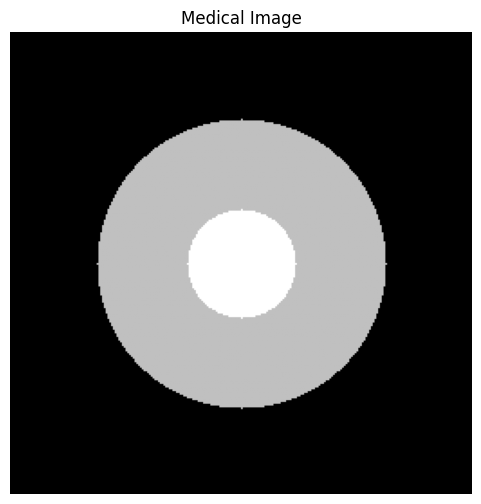

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    image,
    cmap="gray"
)

plt.axis("off")

plt.title("Medical Image")

plt.show()

In [ ]:
resized_image = image.resize(
    (224, 224)
)

print(
    "Resized image size:",
    resized_image.size
)

Resized image size: (224, 224)


In [ ]:
image_array = np.array(
    resized_image
)

print("Image shape:", image_array.shape)
print("Data type:", image_array.dtype)

Image shape: (224, 224)
Data type: uint8


In [ ]:
normalized_image = image_array / 255.0

print(
    "Minimum pixel value:",
    normalized_image.min()
)

print(
    "Maximum pixel value:",
    normalized_image.max()
)

Minimum pixel value: 0.0
Maximum pixel value: 0.9647058823529412


In [ ]:
def inspect_image(image):

    print("========== IMAGE DATA ==========")
    print("Format:", image.format)
    print("Size:", image.size)
    print("Mode:", image.mode)
    inspect_image(image)

Signal Data


In [ ]:
import wfdb

record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("ECG record loaded successfully!")

ECG record loaded successfully!


In [ ]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("ECG annotations loaded successfully!")

ECG annotations loaded successfully!


In [ ]:
print("Sampling frequency:",
      record.fs)

print("Number of samples:",
      record.sig_len)

print("Number of channels:",
      record.n_sig)

Sampling frequency: 360
Number of samples: 650000
Number of channels: 2


In [ ]:
signal = record.p_signal

print("Signal shape:",
      signal.shape)
ecg = signal[:, 0]

print(
    "ECG signal length:",
    len(ecg)
)
print(ecg[:20])

Signal shape: (650000, 2)
ECG signal length: 650000
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135
 -0.145 -0.15  -0.16  -0.155 -0.16  -0.175 -0.18  -0.185 -0.17  -0.155]


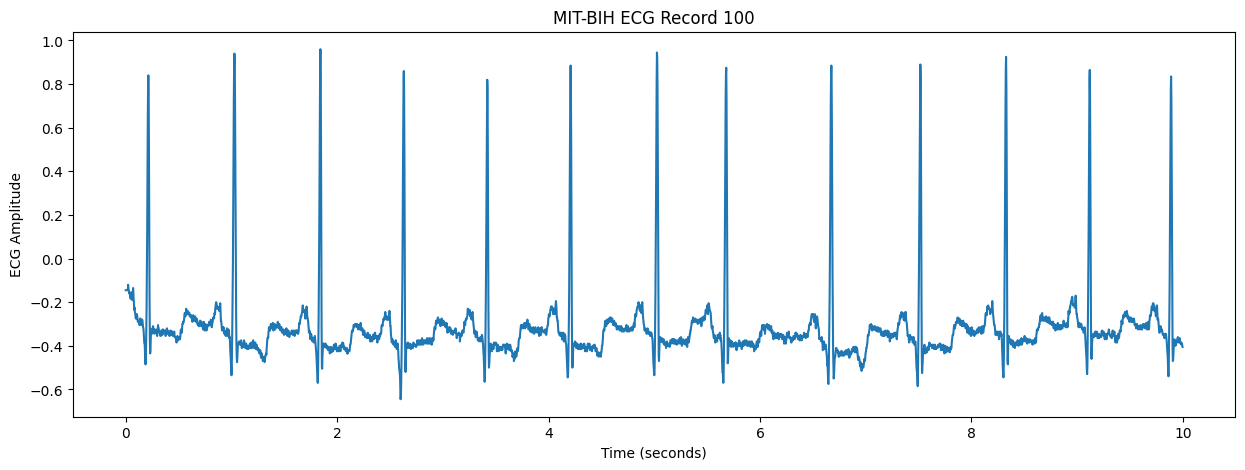

In [ ]:
seconds = 10

samples = int(
    seconds * record.fs
)

time = np.arange(samples) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg[:samples]
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("MIT-BIH ECG Record 100")

plt.show()

In [ ]:
print(
    "First 20 annotation positions:"
)

print(annotation.sample[:20])

First 20 annotation positions:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [ ]:
print(
    "\nFirst 20 annotation symbols:"
)

print(annotation.symbol[:20])


First 20 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [ ]:
annotation_times = (
    annotation.sample / record.fs
)

print(annotation_times[:20])

[ 0.05        0.21388889  1.02777778  1.83888889  2.62777778  3.41944444
  4.20833333  5.025       5.67777778  6.67222222  7.51666667  8.32777778
  9.11666667  9.88888889 10.72777778 11.58333333 12.40555556 13.23333333
 14.05555556 14.85      ]


In [ ]:
symbol_counts = Counter(
    annotation.symbol
)

print(symbol_counts)

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


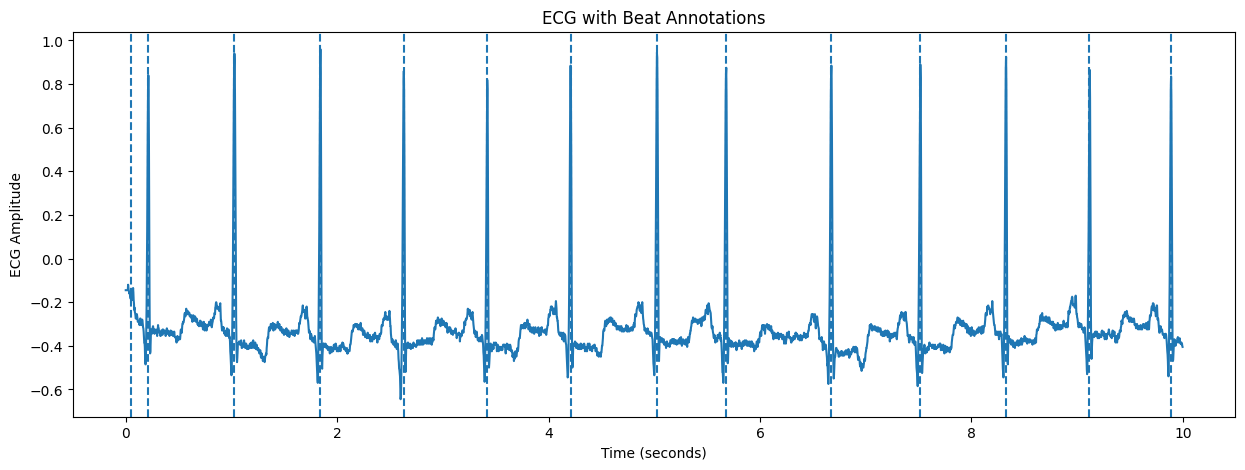

In [ ]:
seconds = 10

samples = int(
    seconds * record.fs
)

time = np.arange(samples) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg[:samples]
)

for sample, symbol in zip(
    annotation.sample,
    annotation.symbol
):

    if sample < samples:

        plt.axvline(
            sample / record.fs,
            linestyle="--"
        )

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("ECG with Beat Annotations")

plt.show()

In [ ]:
normal_beats = [
    sample
    for sample, symbol in zip(
        annotation.sample,
        annotation.symbol
    )
    if symbol == "N"
]

print(
    "Number of normal beats:",
    len(normal_beats)
)

Number of normal beats: 2239


In [ ]:
rr_samples = np.diff(
    normal_beats
)

rr_intervals = (
    rr_samples / record.fs
)

print(
    "First 20 RR intervals:"
)

print(
    rr_intervals[:20]
)
mean_rr = np.mean(
    rr_intervals
)

print(
    "Mean RR interval:",
    mean_rr,
    "seconds"
)
heart_rate = 60 / mean_rr

print(
    "Approximate heart rate:",
    heart_rate,
    "BPM"
)


First 20 RR intervals:
[0.81388889 0.81111111 0.78888889 0.79166667 0.78888889 0.81666667
 1.64722222 0.84444444 0.81111111 0.78888889 0.77222222 0.83888889
 0.85555556 0.82222222 0.82777778 0.82222222 0.79444444 0.79722222
 0.79166667 0.82222222]
Mean RR interval: 0.8066651772415847 seconds
Approximate heart rate: 74.38030262465496 BPM


In [ ]:
rr_std = np.std(
    rr_intervals
)

print(
    "RR interval standard deviation:",
    rr_std,
    "seconds"
)

RR interval standard deviation: 0.1006649427327319 seconds


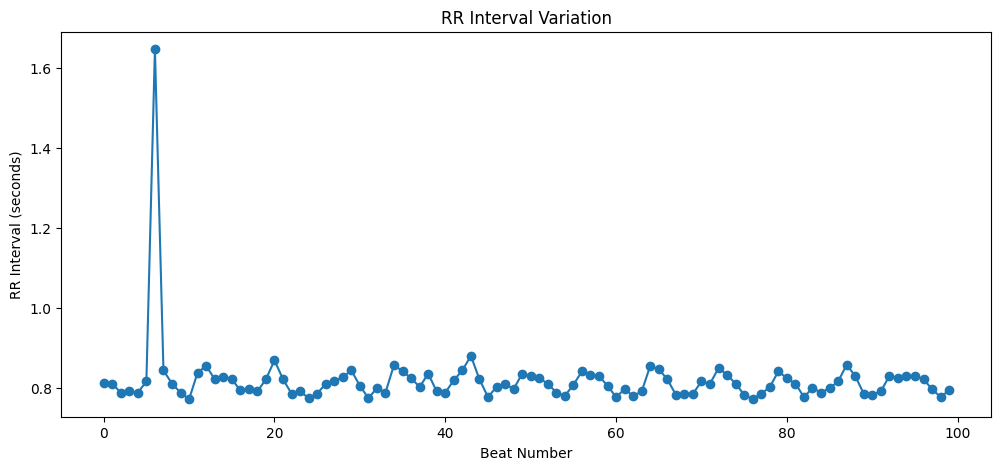

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    rr_intervals[:100],
    marker="o"
)

plt.xlabel("Beat Number")
plt.ylabel("RR Interval (seconds)")
plt.title("RR Interval Variation")

plt.show()

In [ ]:
def inspect_ecg(record):

    print("========== ECG SIGNAL ==========")
    print("Sampling frequency:",
          record.fs,
          "Hz")

    print("Number of samples:",
          record.sig_len)

    print("Number of channels:",
          record.n_sig)

    print("Signal shape:",
          record.p_signal.shape)

Medical Data

In [ ]:
integrated_data = pd.DataFrame({

    "patient_id": [1],

    "age": [55],

    "sex": [1],

    "cholesterol": [240],

    "resting_bp": [140],

    "heart_rate": [
        round(heart_rate, 2)
    ],

    "mean_rr": [
        round(mean_rr, 4)
    ],

    "clinical_note": [
        "Patient reports chest pain during physical activity."
    ],

    "image_file": [
        "synthetic_medical_image.png"
    ],

    "ecg_record": [
        "MIT-BIH record 100"
    ]
})

display(integrated_data)

,patient_id,age,sex,cholesterol,resting_bp,heart_rate,mean_rr,clinical_note,image_file,ecg_record
0,1,55,1,240,140,74.38,0.8067,Patient reports chest pain during physical act...,synthetic_medical_image.png,MIT-BIH record 100


In [ ]:
def load_data(filename):

    file_type = detect_file_type(filename)

    if file_type == "CSV / Tabular":
        return pd.read_csv(filename)

    elif file_type == "Excel / Tabular":
        return pd.read_excel(filename)

    elif file_type == "JSON / Structured":
        return pd.read_json(filename)

    elif file_type == "Plain Text":
        with open(filename, "r") as file:
            return file.read()

    elif file_type == "Image":
        return Image.open(filename)

    else:
        return None

In [ ]:
data = load_data(
    "heart_data.csv"
)

print(type(data))

display(data.head())

<class 'pandas.core.frame.DataFrame'>


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
def load_medical_image(filename):

    extension = filename.lower()

    if extension.endswith(".dcm"):

        import pydicom

        dataset = pydicom.dcmread(filename)

        return dataset

    elif extension.endswith(".nii") or \
         extension.endswith(".nii.gz"):

        import nibabel as nib

        image = nib.load(filename)

        return image

    else:

        return Image.open(filename)

In [ ]:
!pip install pydicom nibabel
!pip install pymupdf

In [ ]:
!pip install pymupdf
import fitz

def extract_pdf_text(filename):

    document = fitz.open(filename)

    text = ""

    for page in document:
        text += page.get_text()

    return text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 38.3 MB/s eta 0:00:00


In [ ]:
pdf_text = extract_pdf_text(
    "clinical_note.txt"
)

print(pdf_text[:2000])

Patient reports chest pain during physical activity.
The patient experiences shortness of breath and
occasional dizziness.
Resting blood pressure is elevated.
The patient has a history of high cholesterol.



In [ ]:
!ls -F

cleaned_heart_disease.csv  heart_data.csv   medical_data.db
clinical_note.txt	   heart_data.json  sample_data/
data_manifest.json	   heart_data.xlsx  synthetic_medical_image.png


In [ ]:
!pip install sqlalchemy

In [ ]:
from sqlalchemy import create_engine

engine = create_engine(
    "sqlite:///medical_data.db"
)

In [ ]:
df.to_sql(
    "heart_disease",
    engine,
    if_exists="replace",
    index=False
)

303

In [ ]:
sql_data = pd.read_sql(
    "SELECT * FROM heart_disease",
    engine
)

display(sql_data.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
manifest = {
    "project": "Multimodal Medical Data Ingestion",
    "tabular_dataset": {
        "name": "UCI Cleveland Heart Disease Dataset",
        "records": int(len(df)),
        "features": int(len(df.columns) - 1)
    },
    "signal_dataset": {
        "name": "MIT-BIH Arrhythmia Database",
        "record": "100",
        "sampling_frequency": float(record.fs),
        "channels": int(record.n_sig)
    },
    "text_data": {
        "file": "clinical_note.txt",
        "type": "synthetic clinical note"
    },
    "image_data": {
        "file": "synthetic_medical_image.png",
        "size": list(image.size),
        "format": image.format
    }
}

In [ ]:
print(json.dumps(
    manifest,
    indent=4
))

{
    "project": "Multimodal Medical Data Ingestion",
    "tabular_dataset": {
        "name": "UCI Cleveland Heart Disease Dataset",
        "records": 303,
        "features": 13
    },
    "signal_dataset": {
        "name": "MIT-BIH Arrhythmia Database",
        "record": "100",
        "sampling_frequency": 360.0,
        "channels": 2
    },
    "text_data": {
        "file": "clinical_note.txt",
        "type": "synthetic clinical note"
    },
    "image_data": {
        "file": "synthetic_medical_image.png",
        "size": [
            256,
            256
        ],
        "format": "PNG"
    }
}


In [ ]:
with open(
    "data_manifest.json",
    "w"
) as file:

    json.dump(
        manifest,
        file,
        indent=4
    )

print("Manifest saved.")

Manifest saved.


In [ ]:
print("=" * 60)
print("MULTIMODAL MEDICAL DATA INGESTION - FINAL SUMMARY")
print("=" * 60)

print("\n1. TABULAR DATA")
print("Dataset: UCI Cleveland Heart Disease")
print("Records:", len(df))
print("Features:", X.shape[1])
print("Target: Binary Heart Disease")

print("\n2. TEXT DATA")
print("Clinical note processed successfully")
print("Number of tokens:", len(filtered_tokens))

print("\n3. IMAGE DATA")
print("Image loaded successfully")
print("Image size:", image.size)
print("Image mode:", image.mode)

print("\n4. SIGNAL DATA")
print("Dataset: MIT-BIH Arrhythmia Database")
print("ECG Record: 100")
print("Sampling frequency:", record.fs, "Hz")

print("\n5. MACHINE LEARNING")
print("Model: Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\n6. MULTIMODAL PIPELINE")
print("Tabular + Text + Image + ECG")
print("Data ingestion and preprocessing completed.")

print("\n" + "=" * 60)
print("ASSIGNMENT COMPLETED SUCCESSFULLY")
print("=" * 60)

MULTIMODAL MEDICAL DATA INGESTION - FINAL SUMMARY

1. TABULAR DATA
Dataset: UCI Cleveland Heart Disease
Records: 303
Features: 13
Target: Binary Heart Disease

2. TEXT DATA
Clinical note processed successfully
Number of tokens: 20

3. IMAGE DATA
Image loaded successfully
Image size: (256, 256)
Image mode: L

4. SIGNAL DATA
Dataset: MIT-BIH Arrhythmia Database
ECG Record: 100
Sampling frequency: 360 Hz

5. MACHINE LEARNING
Model: Logistic Regression
Accuracy: 0.8852459016393442

6. MULTIMODAL PIPELINE
Tabular + Text + Image + ECG
Data ingestion and preprocessing completed.

ASSIGNMENT COMPLETED SUCCESSFULLY


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("===== FINAL MACHINE LEARNING RESULTS =====")

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {auc:.4f}")

===== FINAL MACHINE LEARNING RESULTS =====
Accuracy: 0.8852

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61


Confusion Matrix:
[[28  5]
 [ 2 26]]

ROC-AUC: 0.9665


In [ ]:
samples = annotation.sample

rr_samples = np.diff(samples)

rr_seconds = rr_samples / record.fs

heart_rates = 60 / rr_seconds

print("===== ECG ANALYSIS =====")
print("Number of annotated beats:", len(samples))
print("Sampling frequency:", record.fs, "Hz")

print("\nFirst 10 RR intervals (seconds):")
print(rr_seconds[:10])

print("\nAverage RR interval:", np.mean(rr_seconds), "seconds")

print("\nAverage heart rate:", np.mean(heart_rates), "BPM")

print("\nRR interval standard deviation:",
      np.std(rr_seconds), "seconds")

===== ECG ANALYSIS =====
Number of annotated beats: 2274
Sampling frequency: 360 Hz

First 10 RR intervals (seconds):
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]

Average RR interval: 0.7943161265092633 seconds

Average heart rate: 75.94458550403931 BPM

RR interval standard deviation: 0.05058434099145012 seconds


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

Accuracy: 0.8852459016393442
Accuracy (%): 88.52459016393442

Confusion Matrix:
[[28  5]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

ROC-AUC: 0.9664502164502166


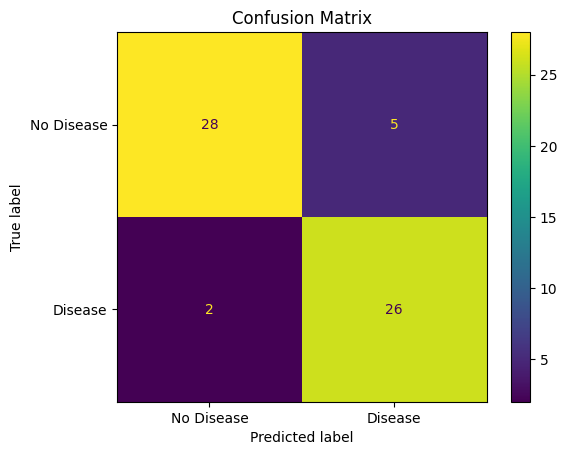

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix")
plt.show()

CSV


In [ ]:
df.to_csv("heart_disease.csv", index=False)

csv_data = pd.read_csv("heart_disease.csv")

print("CSV loaded successfully")
print(csv_data.shape)
display(csv_data.head())

CSV loaded successfully
(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Excel


In [ ]:
df.to_excel("heart_disease.xlsx", index=False)

excel_data = pd.read_excel("heart_disease.xlsx")

print("Excel loaded successfully")
print(excel_data.shape)
display(excel_data.head())

Excel loaded successfully
(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


JSON

In [ ]:
df.to_json(
    "heart_disease.json",
    orient="records"
)

json_data = pd.read_json("heart_disease.json")

print("JSON loaded successfully")
print(json_data.shape)
display(json_data.head())

JSON loaded successfully
(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


SQL


In [ ]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///heart_disease.db")

df.to_sql(
    "heart_disease",
    engine,
    if_exists="replace",
    index=False
)

sql_data = pd.read_sql(
    "SELECT * FROM heart_disease",
    engine
)

print("SQL loaded successfully")
print(sql_data.shape)
display(sql_data.head())

SQL loaded successfully
(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
